# Regression & Supernova 

Fit with linear and then polinomial, looking for the best model regression.

In [4]:
import matplotlib.pyplot as plt
import numpy as np

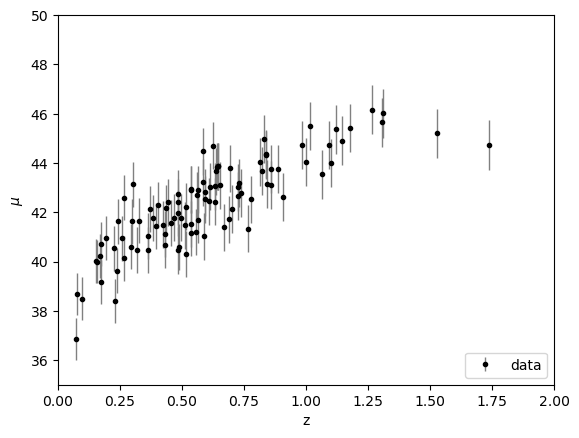

In [5]:
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) 

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

In [19]:
# Cross validation routine

# Z. suggested to pass also eteroschedastic error, but I don't have control over astroML datasets, so I will just ignore it for now.
# I will use the same error for all points, which is not ideal but should be sufficient for this demonstration.

def cross_validation(x, y, model):
    validation_fraction = 0.25
    X = np.asarray(x)
    Y = np.asarray(y)

    n_folds = int(1 / validation_fraction)
    folds = np.array_split(np.arange(len(X)), n_folds)
    training_error = 0
    crossval_error = 0

    for k in range(n_folds):
        start = folds[k][0]
        end = folds[k][-1] + 1

        X_validate = X[start:end]
        Y_validate = Y[start:end]

        X_train = np.concatenate((X[:start], X[end:]), axis=0)
        Y_train = np.concatenate((Y[:start], Y[end:]), axis=0)

        model.fit(X_train[:, np.newaxis], Y_train)
        training_error += np.sum((model.predict(X_train[:, np.newaxis]) - Y_train) ** 2)/len(X_train)
        crossval_error += np.sum((model.predict(X_validate[:, np.newaxis]) - Y_validate) ** 2)/len(X_validate)

    training_error /= n_folds
    crossval_error /= n_folds

    return np.sqrt(training_error), np.sqrt(crossval_error)

def learning_curve(x, y, model, n_points=10):
    X = np.asarray(x)
    Y = np.asarray(y)

    training_errors = []
    crossval_errors = []
    n = []

    for i in range(1, n_points + 1):
        subset_size = int(len(X) * (i / n_points))
        X_subset = X[:subset_size]
        Y_subset = Y[:subset_size]

        tr_err, cv_err = cross_validation(X_subset, Y_subset, model)
        training_errors.append(tr_err)
        crossval_errors.append(cv_err)
        n.append(subset_size)

    return n, training_errors, crossval_errors


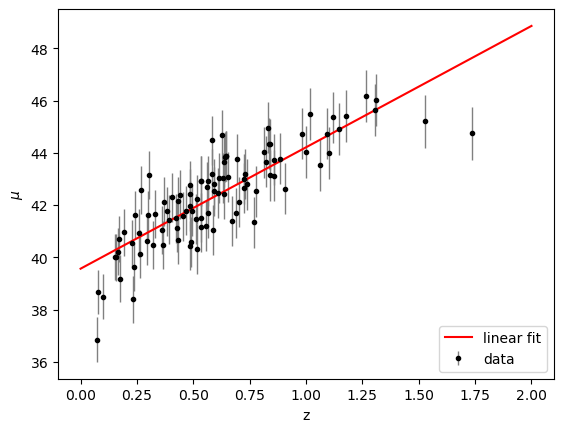

b = 39.56505554722625, a = 4.6471184795912945


In [7]:
# Linear regression

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(z_sample[:, np.newaxis], mu_sample)
z_fit = np.linspace(0, 2, 100)
mu_fit = model.predict(z_fit[:, np.newaxis])

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.plot(z_fit, mu_fit, '-r', label='linear fit')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.show()

theta0 = model.intercept_
theta1 = model.coef_[0]

print("b = {}, a = {}".format(theta0, theta1))

In [8]:
tr_err, cv_err = cross_validation(z_sample, mu_sample, model)
print ("Cross validation score: {}".format(cv_err))
print ("Training error: {}".format(tr_err))

Cross validation score: 1.0403147976240856
Training error: 0.9787899385208895


Degree: 1, Training error: 0.9788, Cross validation error: 1.0403
Degree: 2, Training error: 0.9007, Cross validation error: 0.9377
Degree: 3, Training error: 0.8965, Cross validation error: 1.1903
Degree: 4, Training error: 0.8663, Cross validation error: 1.0447
Degree: 5, Training error: 0.8577, Cross validation error: 3.9798
Degree: 6, Training error: 0.8515, Cross validation error: 12.4319
Degree: 7, Training error: 0.8425, Cross validation error: 0.9405
Degree: 8, Training error: 0.8415, Cross validation error: 12.7672


/opt/anaconda3/envs/astrostats/lib/python3.11/site-packages/astroML/linear_model/linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


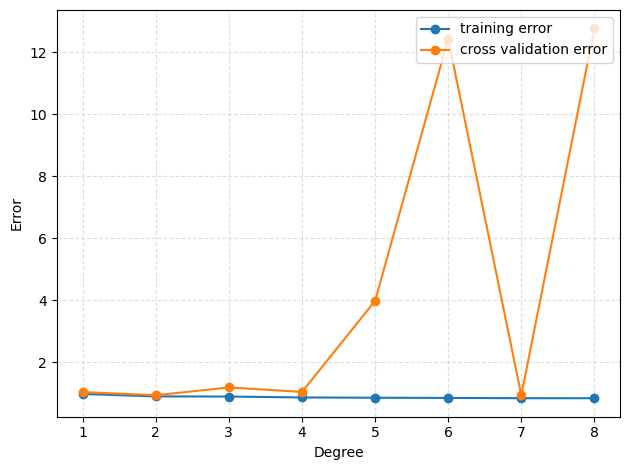

In [9]:
# Polynomial regression

from astroML.linear_model import PolynomialRegression

d = np.arange(1, 9)
training_err = np.zeros(d.shape)
crossval_err = np.zeros(d.shape)

for i, degree in enumerate(d):
    model = PolynomialRegression(degree=degree)
    model.fit(z_sample[:, np.newaxis], mu_sample)
    tr_err, cv_err = cross_validation(z_sample, mu_sample, model)

    training_err[i] = tr_err
    crossval_err[i] = cv_err

    print(
        "Degree: {}, Training error: {:.4f}, Cross validation error: {:.4f}".format(
            degree, tr_err, cv_err
        )
    )

plt.plot(d, training_err, "-o", label="training error")
plt.plot(d, crossval_err, "-o", label="cross validation error")
plt.xlabel("Degree")
plt.ylabel("Error")
plt.xticks(d)
plt.grid(alpha=0.4, linestyle="--")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

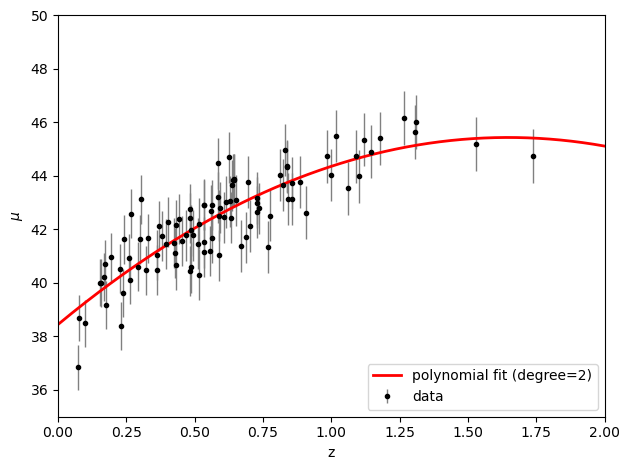

In [10]:
best_idx = np.argmin(crossval_err)
best_degree = d[best_idx]

best_model = PolynomialRegression(degree=best_degree)
best_model.fit(z_sample[:, np.newaxis], mu_sample)

z_fit = np.linspace(0, 2, 200)
mu_fit = best_model.predict(z_fit[:, np.newaxis])

plt.errorbar(z_sample, mu_sample, dmu, fmt=".k", ecolor="gray", lw=1, label="data")
plt.plot(z_fit, mu_fit, "-r", lw=2, label=f"polynomial fit (degree={best_degree})")
plt.xlabel("z")
plt.ylabel("$\\mu$")
plt.xlim(0, 2)
plt.ylim(35, 50)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

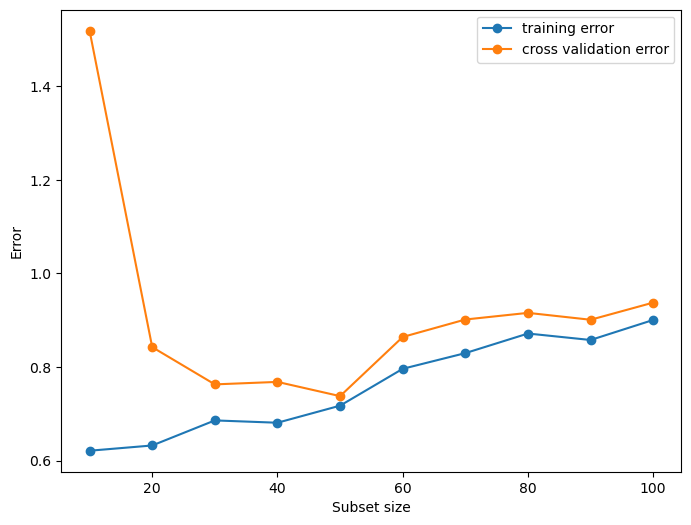

In [23]:
n, training_errors, crossval_errors = learning_curve(z_sample, mu_sample, best_model, n_points=10)

plt.figure(figsize=(8, 6))
plt.plot(n, training_errors, "-o", label="training error")
plt.plot(n, crossval_errors, "-o", label="cross validation error")
plt.xlabel("Subset size")
plt.ylabel("Error")
plt.legend(loc="upper right")


We see the convergence between training and validation. Naturally both curves increase as we train and validate on more data, though the important point is that they stay together. Adding more data will not result in a better fit. If we want to reduce the error, we should look for a more flexible model.